# 实战：统计套利配对交易回测

有了协整理论，本节展示一个完整的、带出入场信号的基于 Z-Score 的配对交易 Python 实现。


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

def get_spread(y, x):
    """
    计算两个协整资产组合的价差 (Spread) 和对冲比例 (Beta)
    假设 y 和 x 都是 pandas Series（过去 N 天的价格）
    """
    # 增加常数项以拟合直线 Y = a + bX
    X_reg = sm.add_constant(x)
    model = sm.OLS(y, X_reg).fit()
    
    # model.params[1] 是斜率，即我们应该持有多少份 X 来对冲 1 份 Y
    beta = model.params.iloc[1] 
    
    # 残差即为对冲后的价差组合
    spread = y - beta * x
    return spread, beta

def generate_signals(spread, z_entry=2.0, z_exit=0.5, window=30):
    """
    根据价差生成交易信号（基于滚动 Z-Score）
    """
    signals = pd.DataFrame(index=spread.index)
    signals['spread'] = spread
    
    # 计算滚动均值和标准差以标准化价差为 Z-Score
    signals['rolling_mean'] = spread.rolling(window=window).mean()
    signals['rolling_std'] = spread.rolling(window=window).std()
    signals['z_score'] = (signals['spread'] - signals['rolling_mean']) / signals['rolling_std']
    
    # 初始化仓位记录为 0
    signals['position'] = 0 
    
    current_position = 0 # 1 代表做多Spread, -1 代表做空Spread, 0 代表空仓
    
    for i in range(1, len(signals)):
        z = signals['z_score'].iloc[i]
        
        # 1. 开仓逻辑
        if current_position == 0:
            if z > z_entry:
                # 价差过大，做空：卖出 Y，买入 X
                current_position = -1
            elif z < -z_entry:
                # 价差过小，做多：买入 Y，卖出 X
                current_position = 1
                
        # 2. 平仓（均值回归）逻辑
        elif current_position == -1:
            if z < z_exit:
                current_position = 0
        elif current_position == 1:
            if z > -z_exit:
                current_position = 0
                
        signals['position'].iloc[i] = current_position
        
    return signals


In [2]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

### 模拟协整数据进行回测验证


计算得出的历史对冲系数 (Beta): 2.53


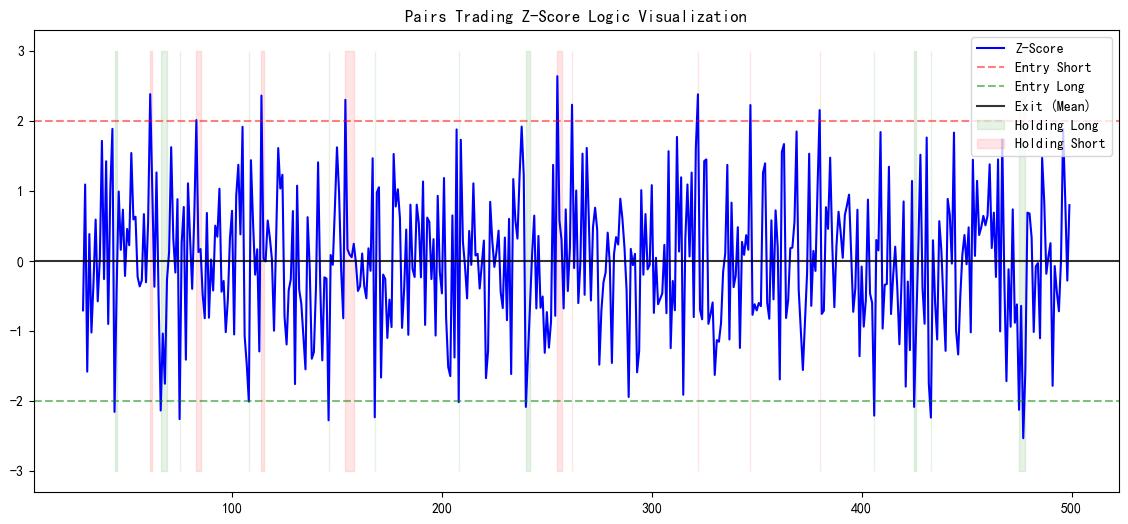

In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt


def get_spread(y, x):
    """计算对冲比例和价差"""
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    hedge_ratio = model.params.iloc[1]
    spread = y - hedge_ratio * x
    return spread, hedge_ratio

def generate_signals(spread, z_entry=2.0, z_exit=0.0, window=30):
    """生成交易信号（高性能无报错版）"""
    # 1. 计算 Z-Score
    spread_mean = spread.rolling(window=window).mean()
    spread_std = spread.rolling(window=window).std()
    z_score = (spread - spread_mean) / spread_std
    
    signals = pd.DataFrame({'spread': spread, 'z_score': z_score})
    
    # 2. 使用数组暂存仓位
    positions = np.zeros(len(signals))
    current_position = 0
    
    z_values = signals['z_score'].values # 转成 numpy 数组 遍历更快
    
    for i in range(len(z_values)):
        z = z_values[i]
        
        if np.isnan(z):
            positions[i] = 0
            continue
            
        # 核心逻辑：开平仓
        if z > z_entry:
            current_position = -1      # 做空价差
        elif z < -z_entry:
            current_position = 1       # 做多价差
        elif current_position == -1 and z <= z_exit:
            current_position = 0       # 做空平仓
        elif current_position == 1 and z >= -z_exit:
            current_position = 0       # 做多平仓
            
        positions[i] = current_position
        
    # 3. 循环结束后，一次性赋值回 DataFrame
    signals['position'] = positions
    return signals

# --- 主逻辑 ---
np.random.seed(42)
x = np.cumsum(np.random.normal(0, 1, 500)) + 100
x_series = pd.Series(x)

noise = np.random.normal(0, 5, 500)
y = 2.5 * x + 50 + noise 
y_series = pd.Series(y)

whole_spread, hedge_ratio = get_spread(y_series, x_series)
print(f"计算得出的历史对冲系数 (Beta): {hedge_ratio:.2f}")

signals_df = generate_signals(whole_spread, z_entry=2.0, z_exit=0.0, window=30)

# 结果可视化
plt.figure(figsize=(14, 6))
plt.plot(signals_df.index, signals_df['z_score'], label='Z-Score', color='blue')
plt.axhline(2.0, color='red', linestyle='--', alpha=0.5, label='Entry Short')
plt.axhline(-2.0, color='green', linestyle='--', alpha=0.5, label='Entry Long')
plt.axhline(0.0, color='black', alpha=0.8, label='Exit (Mean)')

# 画出实际持仓的时间段
plt.fill_between(signals_df.index, -3, 3, where=signals_df['position']==1, color='green', alpha=0.1, label='Holding Long')
plt.fill_between(signals_df.index, -3, 3, where=signals_df['position']==-1, color='red', alpha=0.1, label='Holding Short')

plt.title("Pairs Trading Z-Score Logic Visualization")
plt.legend()
plt.show()

## 4. 计算策略的累计收益 (Strategy PNL) 与资金曲线

有了按天的交易信号（1=做多差价组合，-1=做空差价组合，0=空仓），我们可以进一步计算该策略每天的真实盈亏（PNL）。

**注意：** 真实的配对交易需要考虑两只股票各自的价格波动量，而不仅仅是差价本身。我们先用一个简化的模型：
日盈亏 = 前一天的仓位信号 * 差价在当天的变动值


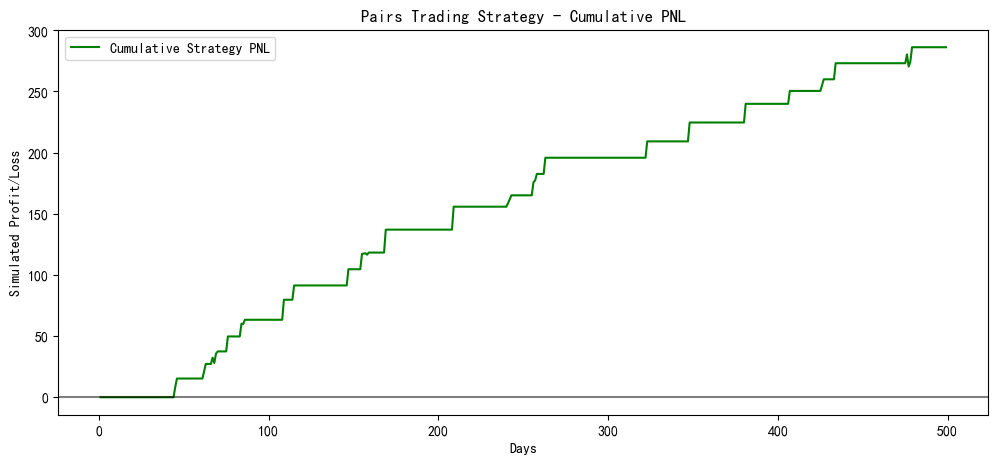

策略估算年化夏普比率: 3.45


In [7]:
# 简化版的资金曲线回测
# 每天的收益率 = 昨天的仓位方向 * 今天的差价变动 (差分的 Spread)
signals_df['spread_diff'] = signals_df['spread'].diff()
signals_df['strategy_pnl'] = signals_df['position'].shift(1) * signals_df['spread_diff']

# 累计收益 (Cumulative PNL)
signals_df['cumulative_pnl'] = signals_df['strategy_pnl'].cumsum()

# 绘制资金曲线
plt.figure(figsize=(12, 5))
plt.plot(signals_df.index, signals_df['cumulative_pnl'], color='green', label='Cumulative Strategy PNL')
plt.axhline(0, color='black', alpha=0.5)
plt.title('Pairs Trading Strategy - Cumulative PNL')
plt.xlabel('Days')
plt.ylabel('Simulated Profit/Loss')
plt.legend()
plt.show()

# 计算简单的夏普比率 (假设无风险利率为 0)
daily_pnl = signals_df['strategy_pnl'].dropna()
if daily_pnl.std() != 0:
    sharpe_ratio = np.sqrt(252) * (daily_pnl.mean() / daily_pnl.std())
    print(f"策略估算年化夏普比率: {sharpe_ratio:.2f}")


### 核心陷阱与警告 (Warnings)
目前我们在计算 `get_spread` 时，使用了**未来信息**，即将全部 500 天的数据喂入 OLS 回归拿到了一个常数 Beta。这在实盘中是致命的（Lookahead Bias）。

在下一章节 `07_kalman_filter_applications.ipynb` 中，我们将介绍如何使用卡尔曼滤波器，真正在做到“只看昨天，预测今天”，彻底消除这个未来函数。

## 结语
本代码演示了统计套利最经典的 Z-Score 交易逻辑框架。
配对交易并不是包赚不赔的，如果遇到单边极端行情导致“关系破裂”，Z-score 会无限拉长，此时如果不设置止损（Stop-loss），做多/做空带来的无限敞口会摧毁整个账户。

在实际生产环境中：
1.  不要使用全历史或滚动 OLS 计算 Beta，请使用**卡尔曼滤波**。
2.  必须加入**滑点 (Slippage)** 和 **手续费 (Commissions)** 摩擦计算。
3.  必须设置强制止损线（例如 Z-Score > 4 时平头寸离场）。


## 🎯 练习

1. 尝试修改入场阈值（`z_entry`）为 1.5 和 2.5，对比哪种参数的夏普比率更高。
2. 添加止损逻辑：当 Z-Score 超过 3.5 时强制平仓，观察对最大回撤的影响。
3. 将模拟数据替换成真实的沪深两市同板块股票对（如宁德时代 vs 比亚迪），运行完整回测。

---
**下一节** → `07_kalman_filter_applications.ipynb`
